# Week 6 - MNIST Autoencoder

## Importing required packages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim as optim
from torchvision import datasets, transforms


## Defining transforms

In [ ]:
to_tensor_transform = transforms.ToTensor()


## Downloading the required data

In [ ]:
mnist_train = datasets.MNIST("mnist_data", train=True, download=True, transform=to_tensor_transform)
mnist_test = datasets.MNIST("mnist_data", train=False, download=True, transform=to_tensor_transform)


100%|██████████| 9.91M/9.91M [00:00<00:00, 132MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 34.6MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 84.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.78MB/s]


## Defining dataloaders

In [ ]:
val_fraction = 0.2

# IMPORTANT
batch_size = 20

loader_workers = 0

sample_total = len(mnist_train)

# indices used to split the training set into training and validation portions
shuffled_positions = list(range(sample_total))

np.random.shuffle(shuffled_positions)
split_point = int(np.floor(val_fraction * sample_total))
train_positions, val_positions = shuffled_positions[split_point:], shuffled_positions[:split_point]

# samplers pick out the right subset of indices for each loader
train_sampler = SubsetRandomSampler(train_positions)
val_sampler = SubsetRandomSampler(val_positions)

# dataloaders for training, validation and testing
train_loader = DataLoader(mnist_train, batch_size=batch_size, sampler=train_sampler, num_workers=loader_workers)
valid_loader = DataLoader(mnist_train, batch_size=batch_size, sampler=val_sampler, num_workers=loader_workers)
test_loader = DataLoader(mnist_test, batch_size=batch_size, num_workers=loader_workers)


In [ ]:
# lengths of the train, valid and test dataloaders
# NOTE: batch size here is 20
len(train_loader), len(valid_loader), len(test_loader)


(2400, 600, 500)

In [ ]:
# checking a batch of our data
batch_iterator = iter(train_loader)
digit_images, digit_labels = next(batch_iterator)
print(digit_images, digit_images.shape, len(digit_images), digit_images[0].shape)
print()
print(digit_labels, digit_labels.shape, len(digit_labels))


tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

## Visualizing a training batch

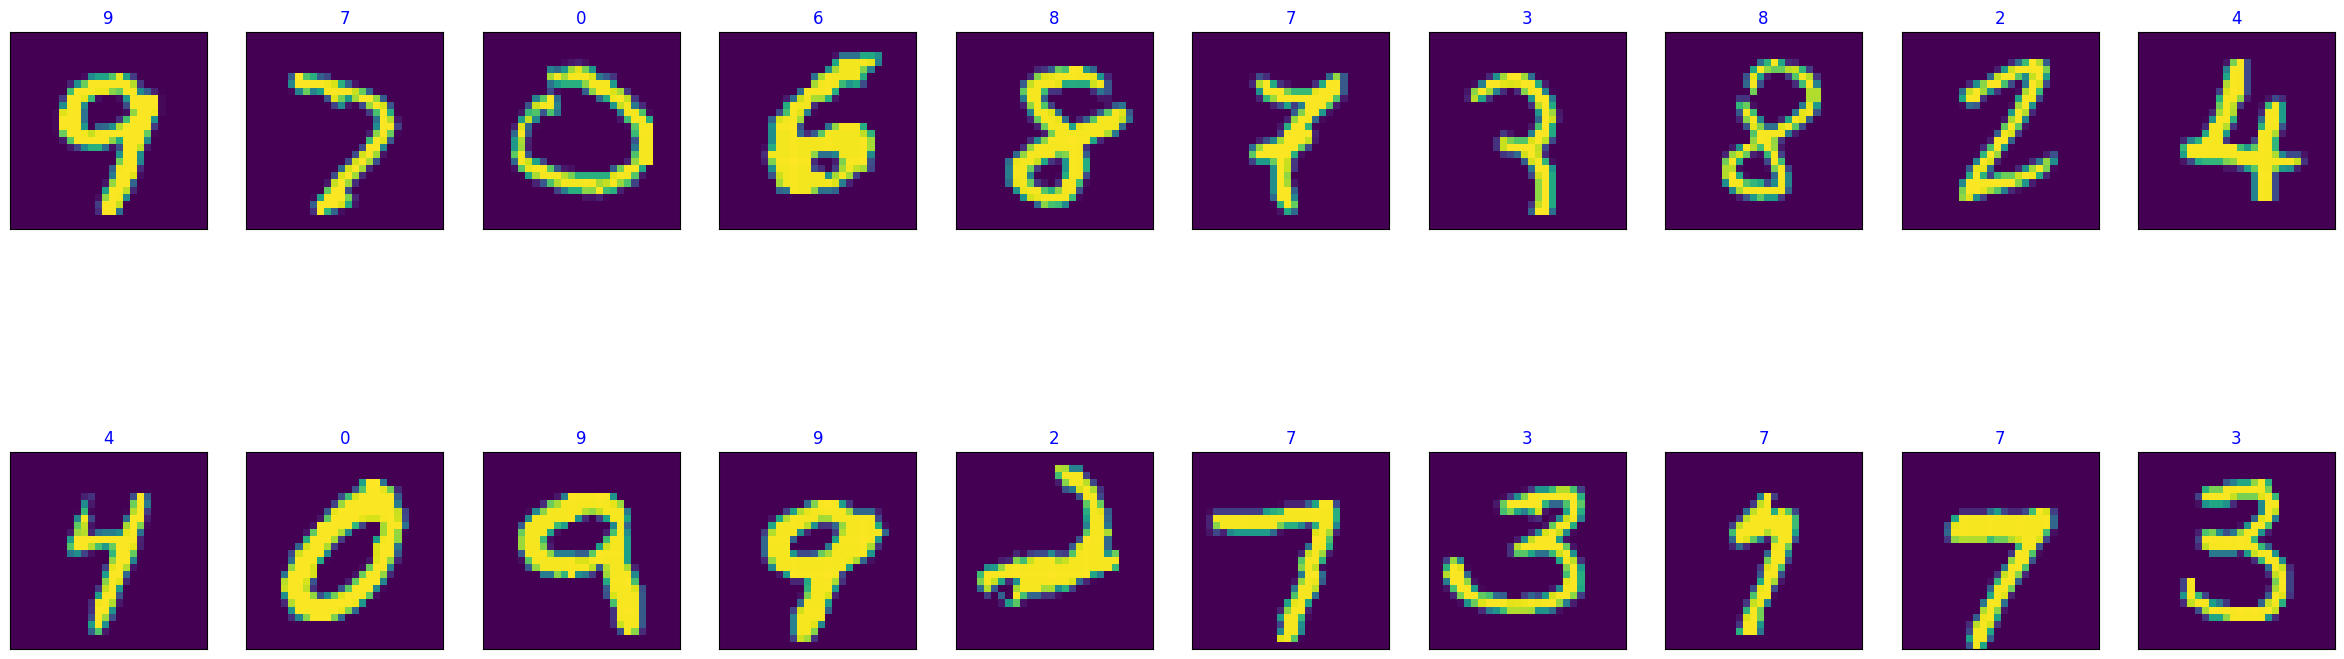

In [ ]:
# displaying images and labels of a batch
fig = plt.figure(figsize=(30, 10))
for position in range(len(digit_labels)):
    ax = fig.add_subplot(2, 10, position + 1, xticks=[], yticks=[])
    plt.imshow(np.squeeze(digit_images[position]))
    ax.set_title(digit_labels[position].item(), color="blue")


## Defining architecture

In [ ]:
class DenseAutoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(DenseAutoencoder, self).__init__()
        self.encoder = nn.Linear(784, latent_dim)
        self.decoder = nn.Linear(latent_dim, 784)

    def forward(self, x):
        x = F.relu(self.encoder(x))
        x = torch.sigmoid(self.decoder(x))
        return x


class TransposeConvAutoencoder(nn.Module):
    def __init__(self):
        super(TransposeConvAutoencoder, self).__init__()
        self.encoder_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.encoder_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.downsample = nn.MaxPool2d(2, 2)

        self.decoder_conv1 = nn.ConvTranspose2d(4, 16, 2, stride=2)
        self.decoder_conv2 = nn.ConvTranspose2d(16, 1, 2, stride=2)

    def forward(self, x):
        x = self.downsample(F.relu(self.encoder_conv1(x)))
        x = self.downsample(F.relu(self.encoder_conv2(x)))
        x = F.relu(self.decoder_conv1(x))
        x = torch.sigmoid(self.decoder_conv2(x))
        return x


class UpsampleConvAutoencoder(nn.Module):
    def __init__(self):
        super(UpsampleConvAutoencoder, self).__init__()
        self.encoder_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.encoder_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.downsample = nn.MaxPool2d(2, 2)

        self.decoder_conv1 = nn.Conv2d(4, 16, 3, padding=1)
        self.decoder_conv2 = nn.Conv2d(16, 1, 3, padding=1)

    def forward(self, x):
        x = self.downsample(F.relu(self.encoder_conv1(x)))
        x = self.downsample(F.relu(self.encoder_conv2(x)))
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = F.relu(self.decoder_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = torch.sigmoid(self.decoder_conv2(x))
        return x

# pixel values are normalized between 0 and 1, so a sigmoid activation on the
# output layer keeps the reconstruction in that same value range


In [ ]:
dense_model = DenseAutoencoder(32)
transpose_model = TransposeConvAutoencoder()
upsample_model = UpsampleConvAutoencoder()

def init_linear_weights(layer):
    layer_type = layer.__class__.__name__
    if layer_type.find("Linear") != -1:
        fan_in = layer.in_features
        spread = 1.0 / np.sqrt(fan_in)
        layer.weight.data.normal_(0, spread)
        layer.bias.data.fill_(0)

dense_model.apply(init_linear_weights)

use_gpu = True
if use_gpu and torch.cuda.is_available():
    dense_model.cuda()
    transpose_model.cuda()
    upsample_model.cuda()
print(dense_model, "\n\n\n\n", transpose_model, "\n\n\n\n", upsample_model, "\n\n\n\n", "On GPU:", torch.cuda.is_available())


DenseAutoencoder(
  (encoder): Linear(in_features=784, out_features=32, bias=True)
  (decoder): Linear(in_features=32, out_features=784, bias=True)
) 



 TransposeConvAutoencoder(
  (encoder_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoder_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downsample): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (decoder_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (decoder_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
) 



 UpsampleConvAutoencoder(
  (encoder_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoder_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downsample): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (decoder_conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (decoder_conv2): Conv2d(16, 1

## Defining our loss function

In [ ]:
# used when comparing reconstructed pixel values against the originals
pixelwise_loss = nn.MSELoss()


## Training and validation phase

In [ ]:
def train_autoencoder(model, lr, mode="fully"):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # number of epochs to train for
    loss_history = {"train": [], "valid": []}
    total_epochs = 20

    # lowest validation loss seen so far, starts at infinity
    lowest_valid_loss = np.inf

    for epoch in range(total_epochs):
        running_train_loss = 0.0
        running_valid_loss = 0.0

        # training phase
        model.train()
        for images, _ in train_loader:
            if use_gpu and torch.cuda.is_available():
                images = images.cuda()
            if mode == "fully":
                images = images.view(images.size(0), -1)
            optimizer.zero_grad()
            reconstruction = model(images)
            loss = pixelwise_loss(reconstruction, images)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        # validation phase
        model.eval()
        for images, _ in valid_loader:
            if use_gpu and torch.cuda.is_available():
                images = images.cuda()
            if mode == "fully":
                images = images.view(images.size(0), -1)
            reconstruction = model(images)
            loss = pixelwise_loss(reconstruction, images)
            running_valid_loss += loss.item()

        # averaging loss across all batches for this epoch
        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_valid_loss = running_valid_loss / len(valid_loader)

        loss_history["train"].append(epoch_train_loss)
        loss_history["valid"].append(epoch_valid_loss)

        print(f"\nEpoch : {epoch+1}\tTraining Loss : {epoch_train_loss}\tValidation Loss : {epoch_valid_loss}")
        if epoch_valid_loss <= lowest_valid_loss:
            print(f"Validation loss decreased from : {lowest_valid_loss} ----> {epoch_valid_loss} ----> Saving Model.......")
            checkpoint_name = type(model).__name__
            torch.save(model.state_dict(), checkpoint_name + "_model.pth")
            lowest_valid_loss = epoch_valid_loss

    return loss_history


In [ ]:
dense_losses = train_autoencoder(dense_model, 0.01)


Epoch : 1	Training Loss : 0.03587102181821441	Validation Loss : 0.03203675235621631
Validation loss decreased from : inf ----> 0.03203675235621631 ----> Saving Model.......

Epoch : 2	Training Loss : 0.03220560477968926	Validation Loss : 0.03192866439931095
Validation loss decreased from : 0.03203675235621631 ----> 0.03192866439931095 ----> Saving Model.......

Epoch : 3	Training Loss : 0.032010086282001186	Validation Loss : 0.032032185972978675

Epoch : 4	Training Loss : 0.03186203972591708	Validation Loss : 0.03161680158538123
Validation loss decreased from : 0.03192866439931095 ----> 0.03161680158538123 ----> Saving Model.......

Epoch : 5	Training Loss : 0.03179332217201591	Validation Loss : 0.03172291364831229

Epoch : 6	Training Loss : 0.03169450121000409	Validation Loss : 0.031817089409256975

Epoch : 7	Training Loss : 0.03163399845827371	Validation Loss : 0.03180902219687899

Epoch : 8	Training Loss : 0.031605998082862546	Validation Loss : 0.031435559261590244
Validation loss 

In [ ]:
transpose_losses = train_autoencoder(transpose_model, 0.01, "conv")


Epoch : 1	Training Loss : 0.01697482414621239	Validation Loss : 0.0129320073639974
Validation loss decreased from : inf ----> 0.0129320073639974 ----> Saving Model.......

Epoch : 2	Training Loss : 0.012410608254140244	Validation Loss : 0.0119407580466941
Validation loss decreased from : 0.0129320073639974 ----> 0.0119407580466941 ----> Saving Model.......

Epoch : 3	Training Loss : 0.011862755419764047	Validation Loss : 0.011889595730851094
Validation loss decreased from : 0.0119407580466941 ----> 0.011889595730851094 ----> Saving Model.......

Epoch : 4	Training Loss : 0.011601919938111677	Validation Loss : 0.011749819599402448
Validation loss decreased from : 0.011889595730851094 ----> 0.011749819599402448 ----> Saving Model.......

Epoch : 5	Training Loss : 0.011485853519601127	Validation Loss : 0.011349444255853693
Validation loss decreased from : 0.011749819599402448 ----> 0.011349444255853693 ----> Saving Model.......

Epoch : 6	Training Loss : 0.011431860945303924	Validation L

In [ ]:
upsample_losses = train_autoencoder(upsample_model, 0.01, "conv")


Epoch : 1	Training Loss : 0.01414694324407416	Validation Loss : 0.009915789388275394
Validation loss decreased from : inf ----> 0.009915789388275394 ----> Saving Model.......

Epoch : 2	Training Loss : 0.009408098791415492	Validation Loss : 0.008858478824452808
Validation loss decreased from : 0.009915789388275394 ----> 0.008858478824452808 ----> Saving Model.......

Epoch : 3	Training Loss : 0.00884376073081512	Validation Loss : 0.008992999632221957

Epoch : 4	Training Loss : 0.008659498363655682	Validation Loss : 0.008797500183961044
Validation loss decreased from : 0.008858478824452808 ----> 0.008797500183961044 ----> Saving Model.......

Epoch : 5	Training Loss : 0.008604204611231884	Validation Loss : 0.008521297824724267
Validation loss decreased from : 0.008797500183961044 ----> 0.008521297824724267 ----> Saving Model.......

Epoch : 6	Training Loss : 0.008556382938210542	Validation Loss : 0.008379300836628923
Validation loss decreased from : 0.008521297824724267 ----> 0.0083793

In [ ]:
dense_model.load_state_dict(torch.load("DenseAutoencoder_model.pth"))
transpose_model.load_state_dict(torch.load("TransposeConvAutoencoder_model.pth"))
upsample_model.load_state_dict(torch.load("UpsampleConvAutoencoder_model.pth"))


<All keys matched successfully>

## Plotting loss

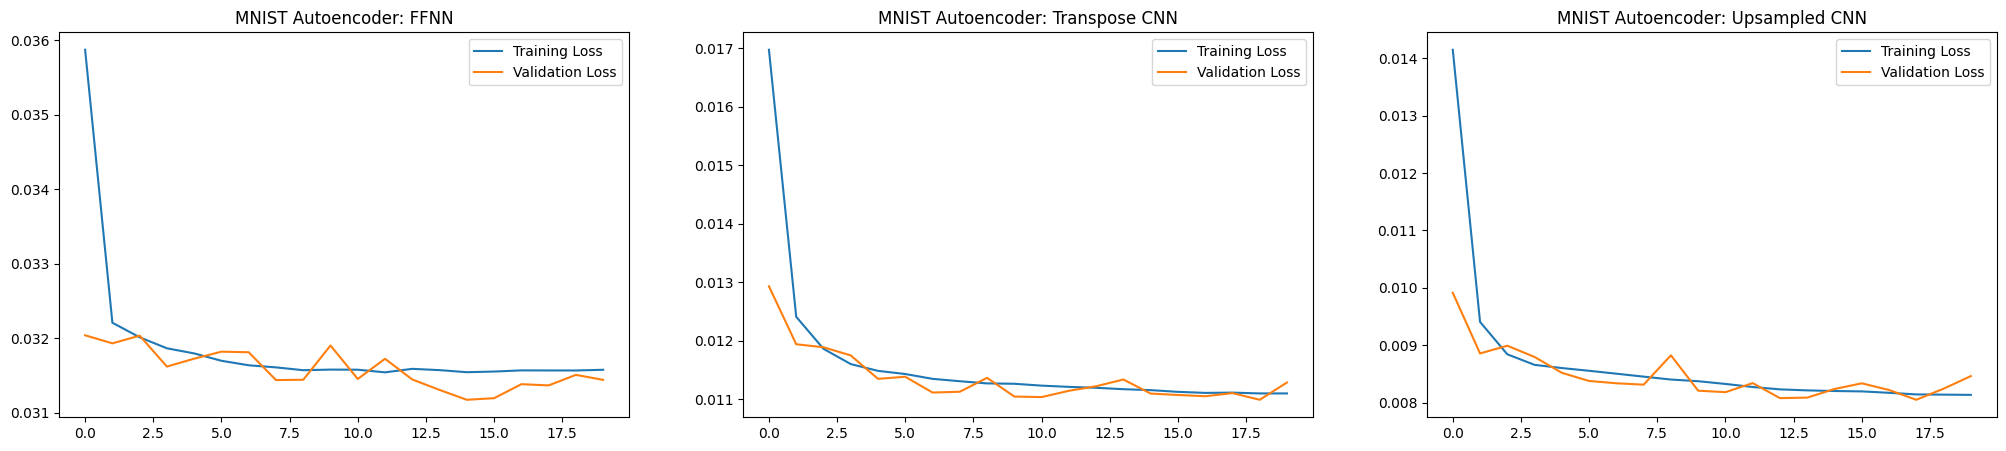

In [ ]:
architecture_titles = ["FFNN", "Transpose CNN", "Upsampled CNN"]
all_loss_histories = [dense_losses, transpose_losses, upsample_losses]

fig = plt.figure(1, figsize=(25, 5))
position = 1
for history in all_loss_histories:
    ax = fig.add_subplot(1, 3, position)
    ax.plot(history["train"], label="Training Loss")
    ax.plot(history["valid"], label="Validation Loss")
    ax.set_title("MNIST Autoencoder: " + architecture_titles[position - 1])
    position += 1
    plt.legend()


## Testing phase

In [ ]:
def evaluate_reconstruction(model, mode="fully"):
    # grab one batch of test images
    batch_iterator = iter(test_loader)
    images, _ = next(batch_iterator)
    if use_gpu and torch.cuda.is_available():
        images = images.cuda()
    if mode == "fully":
        images = images.view(images.size(0), -1)

    # run the model to get reconstructions
    reconstruction = model(images)
    # move originals back to numpy for plotting
    images = images.cpu().numpy()
    # reshape reconstruction into a batch of images
    reconstruction = reconstruction.view(batch_size, 1, 28, 28)
    # detach since this tensor still requires grad
    reconstruction = reconstruction.cpu().detach().numpy()

    # plot the input digits on top and their reconstructions below
    fig, axes = plt.subplots(nrows=2, ncols=10, sharex=True, sharey=True, figsize=(25, 4))

    for image_set, row in zip([images, reconstruction], axes):
        for single_image, ax in zip(image_set, row):
            if mode == "fully":
                single_image = single_image.reshape(1, 28, 28)
            ax.imshow(np.squeeze(single_image), cmap="gray")
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)


## FFNN Autoencoder

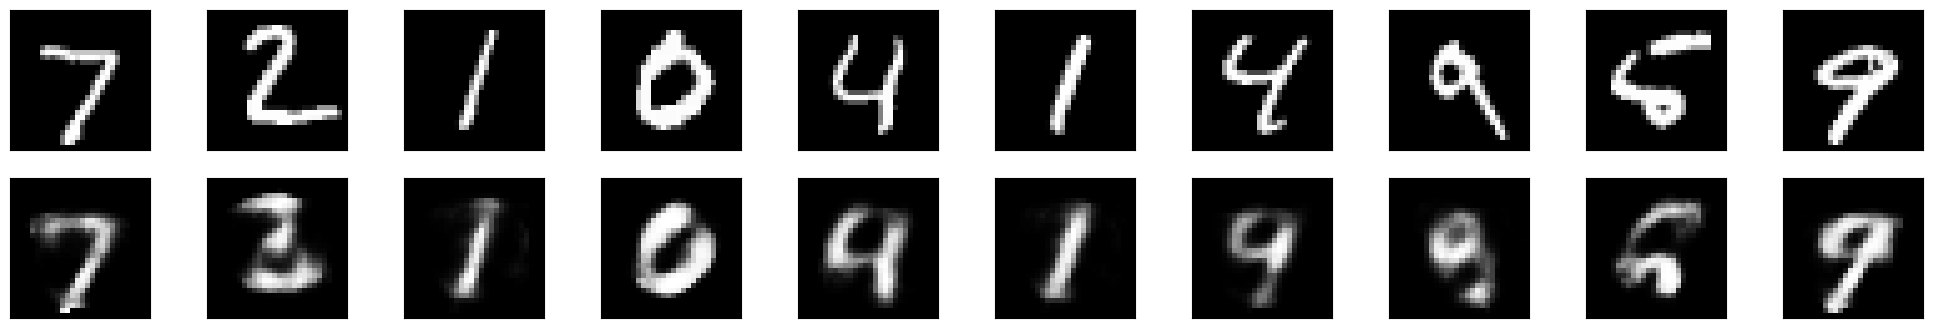

In [ ]:
evaluate_reconstruction(dense_model)

## Transpose CNN Autoencoder

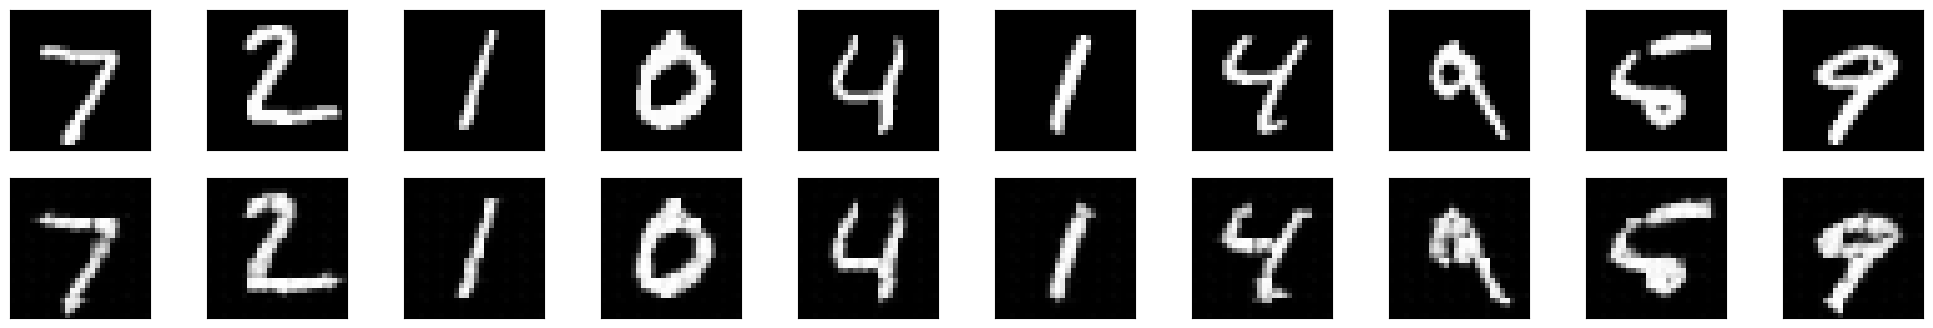

In [ ]:
evaluate_reconstruction(transpose_model, "conv")

## Upsampled CNN Autoencoder

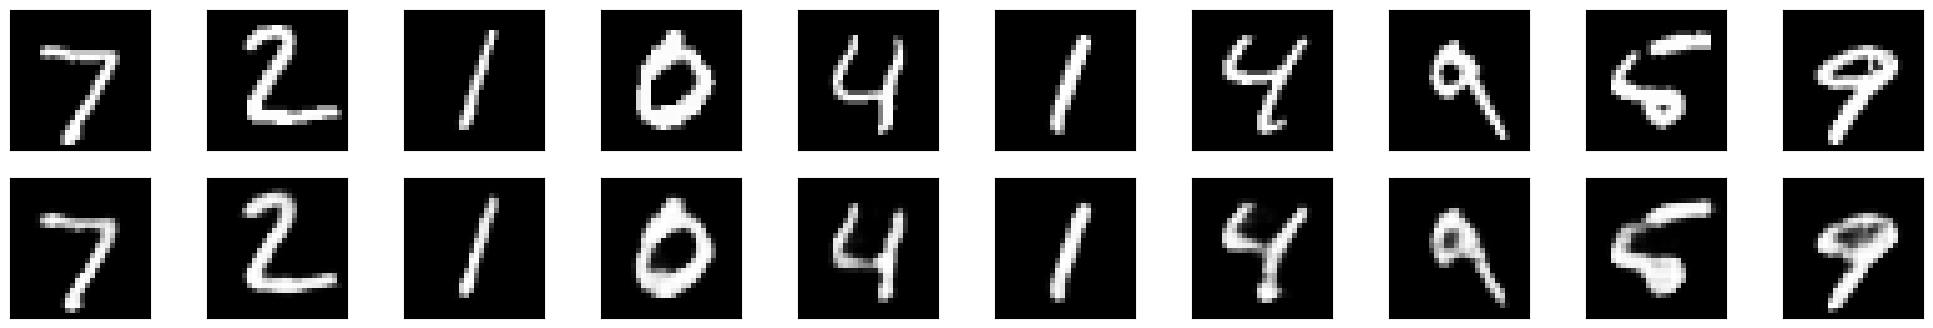

In [ ]:
evaluate_reconstruction(upsample_model, "conv")